# Рабочая тетрадь 6

Решены задания по эволюционным методам: генетический алгоритм и метод имитации отжига. Для обоих заданий используется вариант 1.

Краткий чеклист:
- реализована эволюция популяции из четырёх хромосом за четыре шага;
- посчитаны максимальные значения функции качества и итоговое качество популяции;
- реализован метод имитации отжига для гамильтонова цикла в полном графе `K6`;
- проведён эксперимент с параметром начальной температуры `S`.

In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

WORKBOOK_DIR = Path.cwd()
VARIANT = 1
print(f'Рабочая папка ноутбука: {WORKBOOK_DIR.name}; вариант: {VARIANT}')

Рабочая папка ноутбука: Workbook_6; вариант: 1


## 1. Генетический алгоритм, вариант 1

Начальная популяция состоит из четырёх хромосом с генами `x` и `y`. Качество хромосомы оценивается функцией

$$Z = \frac{x - 3y + 1}{3x^2 + 3y^2 + 1}.$$

На каждом шаге худшая хромосома удаляется, оставшиеся хромосомы сортируются по качеству, после чего применяется схема обмена генами из тетради.

In [2]:
def qZ(x, y):
    return (x - 3 * y + 1) / (3 * x ** 2 + 3 * y ** 2 + 1)


def q_sum(z_values):
    return float(np.sum(z_values))


def quality_order(z_values):
    # Возрастание качества; при равенстве меньший индекс считается хуже,
    # значит больший номер получает предпочтение.
    return sorted(range(len(z_values)), key=lambda idx: (z_values[idx], idx))


def exchange_scheme(old_x, old_y, sorted_ids):
    x = [0] * 4
    y = [0] * 4
    x[2] = old_x[sorted_ids[2]]
    x[3] = old_x[sorted_ids[2]]
    x[0] = old_x[sorted_ids[0]]
    x[1] = old_x[sorted_ids[1]]

    y[0] = old_y[sorted_ids[2]]
    y[1] = old_y[sorted_ids[2]]
    y[2] = old_y[sorted_ids[0]]
    y[3] = old_y[sorted_ids[1]]
    return x, y


def remove_worst(x, y, z_values):
    worst = quality_order(z_values)[0]
    new_x = list(x)
    new_y = list(y)
    new_z = list(z_values)
    removed = {'x': new_x.pop(worst), 'y': new_y.pop(worst), 'Z': new_z.pop(worst), 'index': worst + 1}
    return new_x, new_y, new_z, removed


def population_table(x, y):
    z_values = [qZ(xi, yi) for xi, yi in zip(x, y)]
    return pd.DataFrame({
        'chromosome': range(1, len(x) + 1),
        'x': x,
        'y': y,
        'Z': z_values,
    })


def evolution_steps(x, y, steps=4):
    history = []
    x = list(x)
    y = list(y)
    for step in range(1, steps + 1):
        before = population_table(x, y)
        z_before = before['Z'].tolist()
        survivors_x, survivors_y, survivors_z, removed = remove_worst(x, y, z_before)
        sorted_ids = quality_order(survivors_z)
        x, y = exchange_scheme(survivors_x, survivors_y, sorted_ids)
        after = population_table(x, y)
        history.append({
            'step': step,
            'before': before,
            'removed': removed,
            'after': after,
            'max_Z_before': float(before['Z'].max()),
            'sum_Z_before': float(before['Z'].sum()),
            'max_Z_after': float(after['Z'].max()),
            'sum_Z_after': float(after['Z'].sum()),
        })
    return x, y, history

initial_x = [-2, -1, 0, 1]
initial_y = [-2, -1, 0, 1]
final_x, final_y, ga_history = evolution_steps(initial_x, initial_y, steps=4)

summary_rows = []
for item in ga_history:
    summary_rows.append({
        'Шаг': item['step'],
        'Удалена хромосома': item['removed']['index'],
        'Z удалённой': item['removed']['Z'],
        'max Z до обмена': item['max_Z_before'],
        'sum Z до обмена': item['sum_Z_before'],
        'max Z после обмена': item['max_Z_after'],
        'sum Z после обмена': item['sum_Z_after'],
    })

ga_summary = pd.DataFrame(summary_rows)
ga_summary

,Шаг,Удалена хромосома,Z удалённой,max Z до обмена,sum Z до обмена,max Z после обмена,sum Z после обмена
0,1,4,-0.142857,1.0,1.485714,1.0,1.461538
1,2,1,-0.076923,1.0,1.461538,1.0,2.967033
2,3,1,0.428571,1.0,2.967033,1.0,3.538462
3,4,3,0.538462,1.0,3.538462,1.0,4.000000


In [3]:
for item in ga_history:
    print(f"Шаг {item['step']}: популяция до отбора")
    display(item['before'])
    print('Удалена худшая хромосома:', item['removed'])
    print(f"Шаг {item['step']}: популяция после обмена")
    display(item['after'])

final_population = population_table(final_x, final_y)
print('Финальная популяция после четырёх этапов:')
display(final_population)
print('Максимальное качество в финальной популяции:', final_population['Z'].max())
print('Суммарное качество финальной популяции:', final_population['Z'].sum())

Шаг 1: популяция до отбора


,chromosome,x,y,Z
0,1,-2,-2,0.200000
1,2,-1,-1,0.428571
2,3,0,0,1.000000
3,4,1,1,-0.142857


Удалена худшая хромосома: {'x': 1, 'y': 1, 'Z': -0.14285714285714285, 'index': 4}
Шаг 1: популяция после обмена


,chromosome,x,y,Z
0,1,-2,0,-0.076923
1,2,-1,0,0.000000
2,3,0,-2,0.538462
3,4,0,-1,1.000000


Шаг 2: популяция до отбора


...

Удалена худшая хромосома: {'x': 0, 'y': -2, 'Z': 0.5384615384615384, 'index': 3}
Шаг 4: популяция после обмена


,chromosome,x,y,Z
0,1,0,-1,1.0
1,2,0,-1,1.0
2,3,0,0,1.0
3,4,0,0,1.0


Финальная популяция после четырёх этапов:


,chromosome,x,y,Z
0,1,0,-1,1.0
1,2,0,-1,1.0
2,3,0,0,1.0
3,4,0,0,1.0


Максимальное качество в финальной популяции: 1.0
Суммарное качество финальной популяции: 4.0


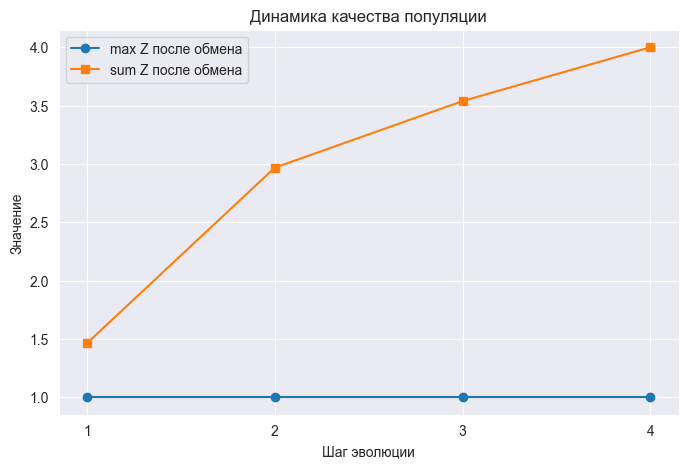

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(ga_summary['Шаг'], ga_summary['max Z после обмена'], marker='o', label='max Z после обмена')
plt.plot(ga_summary['Шаг'], ga_summary['sum Z после обмена'], marker='s', label='sum Z после обмена')
plt.title('Динамика качества популяции')
plt.xlabel('Шаг эволюции')
plt.ylabel('Значение')
plt.xticks(ga_summary['Шаг'])
plt.legend()
plt.show()

Интерпретация: генетический алгоритм сохраняет и комбинирует более качественные хромосомы. Рост максимального значения `Z` показывает, что популяция движется к более полезным решениям.

## 2. Метод имитации отжига, вариант 1

Дан полный граф `K6`, начальный гамильтонов цикл `V = [1, 2, 3, 4, 5, 6, 1]`, последовательность замен `(3,4)`, `(4,6)`, `(5,6)`, `(6,2)` и вероятности `P = [90, 45, 43, 31]` в процентах.

Переход к лучшему решению принимается всегда. Переход к худшему решению принимается, если случайная вероятность меньше или равна вероятности отжига `exp(-Δ/T)`, где `Δ` — ухудшение длины маршрута, `T` — текущая температура.

In [5]:
edges = {
    (1, 2): 26, (1, 3): 42, (1, 4): 44, (1, 5): 31, (1, 6): 24,
    (2, 3): 20, (2, 4): 34, (2, 5): 40, (2, 6): 15,
    (3, 4): 23, (3, 5): 43, (3, 6): 20,
    (4, 5): 27, (4, 6): 22,
    (5, 6): 26,
}
initial_route = [1, 2, 3, 4, 5, 6, 1]
swaps = [(3, 4), (4, 6), (5, 6), (6, 2)]
transition_probabilities = [90, 45, 43, 31]
initial_temperature = 100.0
cooling_rate = 0.5


def edge_length(a, b):
    return edges[tuple(sorted((a, b)))]


def route_length(route):
    return sum(edge_length(a, b) for a, b in zip(route[:-1], route[1:]))


def swap_vertices(route, first_vertex, second_vertex):
    route = list(route)
    core = route[:-1]
    i = core.index(first_vertex)
    j = core.index(second_vertex)
    core[i], core[j] = core[j], core[i]
    return core + [core[0]]


def transition_probability(delta, temperature):
    if delta <= 0:
        return 1.0
    return math.exp(-delta / temperature)


def annealing_run(start_route, swap_plan, p_values, start_temperature=100.0, cooling=0.5):
    current = list(start_route)
    best = list(start_route)
    temperature = float(start_temperature)
    rows = [{
        'Шаг': 'S0',
        'Маршрут': current,
        'Длина': route_length(current),
        'Замена': '-',
        'Температура': temperature,
        'Δ': 0,
        'Вероятность отжига': 1.0,
        'P из задания': '-',
        'Решение': 'начальный маршрут',
    }]

    for step, ((v1, v2), p_percent) in enumerate(zip(swap_plan, p_values), start=1):
        candidate = swap_vertices(current, v1, v2)
        current_len = route_length(current)
        candidate_len = route_length(candidate)
        delta = candidate_len - current_len
        accept_prob = transition_probability(delta, temperature)
        p_value = p_percent / 100
        accepted = delta <= 0 or p_value <= accept_prob
        decision = 'принят' if accepted else 'отклонён'
        if accepted:
            current = candidate
            if route_length(current) < route_length(best):
                best = list(current)
        rows.append({
            'Шаг': f'S{step}',
            'Маршрут': current,
            'Длина': route_length(current),
            'Замена': f'{v1} ↔ {v2}',
            'Температура': temperature,
            'Δ': delta,
            'Вероятность отжига': accept_prob,
            'P из задания': p_value,
            'Решение': decision,
        })
        temperature *= cooling
    return pd.DataFrame(rows), best

annealing_table, best_route = annealing_run(
    initial_route, swaps, transition_probabilities, initial_temperature, cooling_rate
)
annealing_table

,Шаг,Маршрут,Длина,Замена,Температура,Δ,Вероятность отжига,P из задания,Решение
0,S0,"[1, 2, 3, 4, 5, 6, 1]",146,-,100.0,0,1.000000,-,начальный маршрут
1,S1,"[1, 2, 3, 4, 5, 6, 1]",146,3 ↔ 4,100.0,30,0.740818,0.9,отклонён
2,S2,"[1, 2, 3, 6, 5, 4, 1]",163,4 ↔ 6,50.0,17,0.711770,0.45,принят
3,S3,"[1, 2, 3, 5, 6, 4, 1]",181,5 ↔ 6,25.0,18,0.486752,0.43,принят
4,S4,"[1, 2, 3, 5, 6, 4, 1]",181,6 ↔ 2,12.5,24,0.146607,0.31,отклонён


Длина начального маршрута: 146
Лучший найденный маршрут: [1, 2, 3, 4, 5, 6, 1]
Длина лучшего маршрута: 146


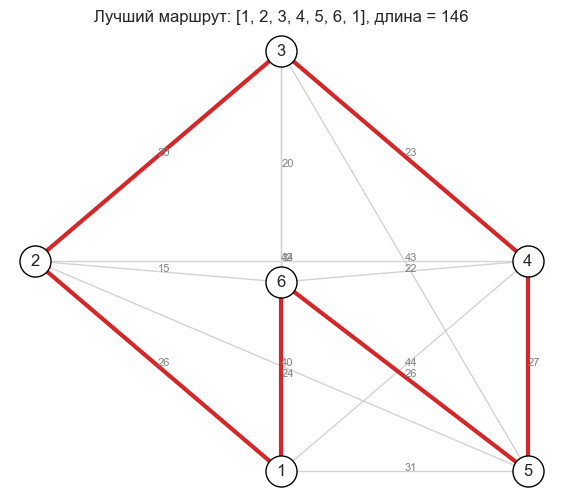

In [6]:
print('Длина начального маршрута:', route_length(initial_route))
print('Лучший найденный маршрут:', best_route)
print('Длина лучшего маршрута:', route_length(best_route))

positions = {
    1: (0.0, 0.0),
    2: (-0.8, 1.0),
    3: (0.0, 2.0),
    4: (0.8, 1.0),
    5: (0.8, 0.0),
    6: (0.0, 0.9),
}

plt.figure(figsize=(7, 6))
for (a, b), length in edges.items():
    xa, ya = positions[a]
    xb, yb = positions[b]
    plt.plot([xa, xb], [ya, yb], color='lightgray', linewidth=1, zorder=1)
    plt.text((xa + xb) / 2, (ya + yb) / 2, str(length), fontsize=8, color='gray')

for a, b in zip(best_route[:-1], best_route[1:]):
    xa, ya = positions[a]
    xb, yb = positions[b]
    plt.plot([xa, xb], [ya, yb], color='tab:red', linewidth=3, zorder=2)

for node, (x_pos, y_pos) in positions.items():
    plt.scatter(x_pos, y_pos, s=500, color='white', edgecolor='black', zorder=3)
    plt.text(x_pos, y_pos, str(node), ha='center', va='center', fontsize=12, zorder=4)

plt.title(f'Лучший маршрут: {best_route}, длина = {route_length(best_route)}')
plt.axis('off')
plt.show()

Интерпретация: в таблице видно, какие перестановки приняты. При высокой температуре алгоритм может принимать худшие маршруты, чтобы выйти из локального минимума; при снижении температуры вероятность таких переходов уменьшается.

## 3. Эксперимент с параметром S

Проверим несколько значений начальной температуры `S`. Чем выше `S`, тем больше вероятность принять временно худший маршрут; чем ниже `S`, тем ближе алгоритм к жадному поиску.

In [8]:
experiment_rows = []
for s_value in [10, 25, 50, 100, 200]:
    table, best = annealing_run(initial_route, swaps, transition_probabilities, s_value, cooling_rate)
    accepted_count = int((table.iloc[1:]['Решение'] == 'принят').sum())
    experiment_rows.append({
        'S': s_value,
        'Принято переходов': accepted_count,
        'Финальная длина': table.iloc[-1]['Длина'],
        'Лучшая длина': route_length(best),
        'Лучший маршрут': best,
    })

experiment_df = pd.DataFrame(experiment_rows)
experiment_df

,S,Принято переходов,Финальная длина,Лучшая длина,Лучший маршрут
0,10,1,148,146,"[1, 2, 3, 4, 5, 6, 1]"
1,25,1,148,146,"[1, 2, 3, 4, 5, 6, 1]"
2,50,1,163,146,"[1, 2, 3, 4, 5, 6, 1]"
3,100,2,181,146,"[1, 2, 3, 4, 5, 6, 1]"
4,200,3,205,146,"[1, 2, 3, 4, 5, 6, 1]"


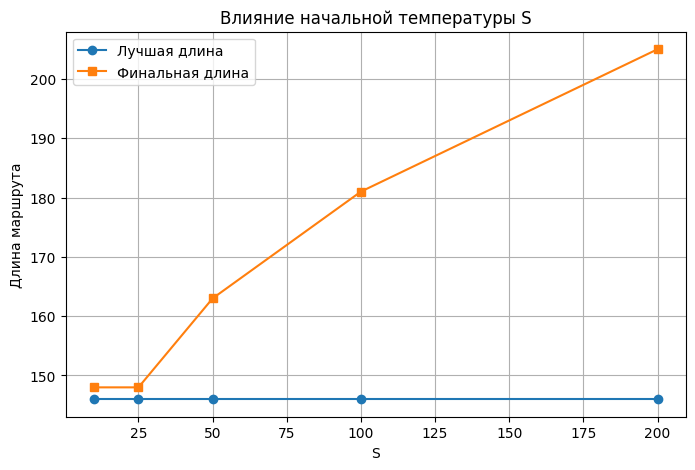

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(experiment_df['S'], experiment_df['Лучшая длина'], marker='o', label='Лучшая длина')
plt.plot(experiment_df['S'], experiment_df['Финальная длина'], marker='s', label='Финальная длина')
plt.title('Влияние начальной температуры S')
plt.xlabel('S')
plt.ylabel('Длина маршрута')
plt.legend()
plt.show()

Вывод по эксперименту: увеличение `S` делает алгоритм менее строгим на ранних шагах и повышает шанс принять ухудшение. Это полезно для выхода из локальных минимумов, но слишком высокая температура может дольше удерживать алгоритм в случайном блуждании.